<a href="https://colab.research.google.com/github/Chandhana-sanoj/ICT_DSA_2026/blob/main/Unsupervised_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

##Load Dataset

In [2]:
df = pd.read_csv("/content/adult_dataset.csv")

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [3]:
print(df.shape)

df.info()

df.describe()

(48842, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


##Missing Values

In [4]:
df.isnull().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [5]:
df.replace("?", np.nan, inplace=True)
df.replace(" ?", np.nan, inplace=True)

df.isnull().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


##Separate Features

In [6]:
income_col = df["income"]

df_cluster = df.drop("income", axis=1)

##Numerical & Categorical Columns

In [7]:
num_cols = df_cluster.select_dtypes(include=np.number).columns.tolist()

cat_cols = df_cluster.select_dtypes(include="object").columns.tolist()

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical Columns:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


##Outlier Detection

In [8]:
for col in num_cols:

    Q1 = df_cluster[col].quantile(0.25)
    Q3 = df_cluster[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_cluster[col] = np.where(
        df_cluster[col] < lower,
        lower,
        np.where(df_cluster[col] > upper,
                 upper,
                 df_cluster[col])
    )

print("Outliers handled using IQR capping")

Outliers handled using IQR capping


##Preprocessing

In [9]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [10]:
X_processed = preprocessor.fit_transform(df_cluster)

print(X_processed.shape)

(48842, 105)


##EDA

##Numerical Distributions

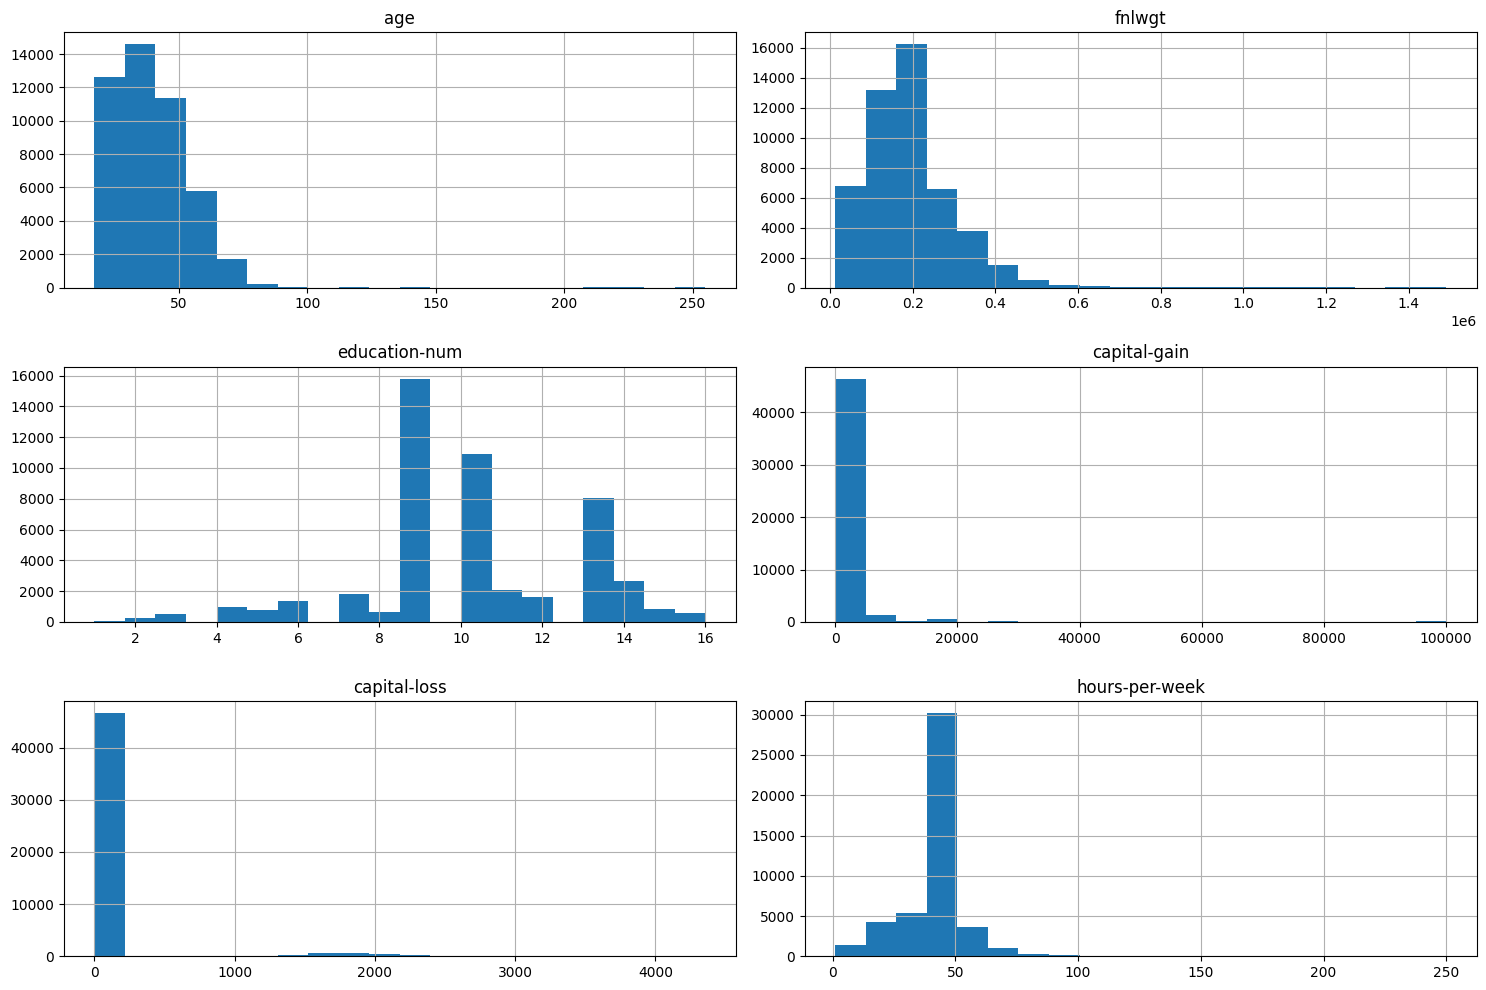

In [11]:
df[num_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

##Correlation Heatmap

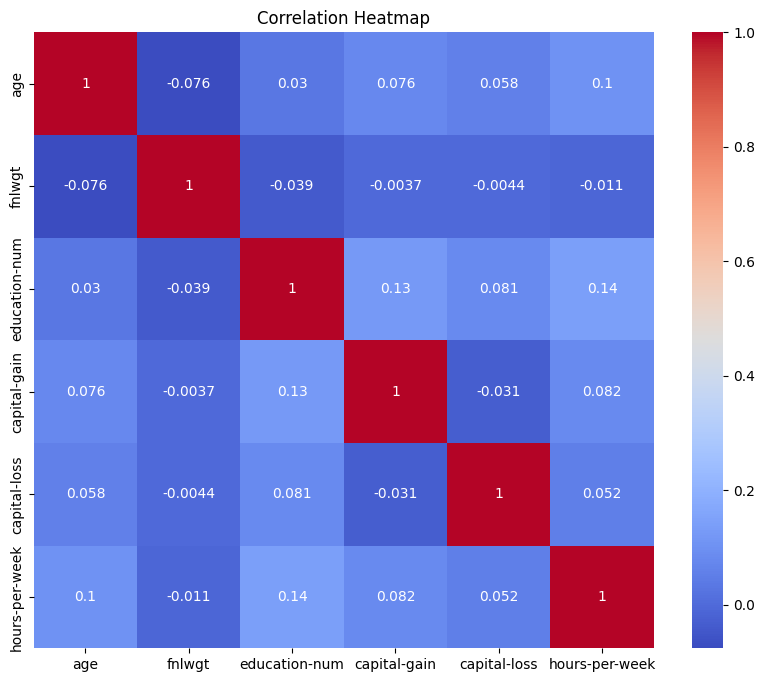

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

##PCA

In [13]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_processed)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.18108072 0.13305041]


##Elbow Method

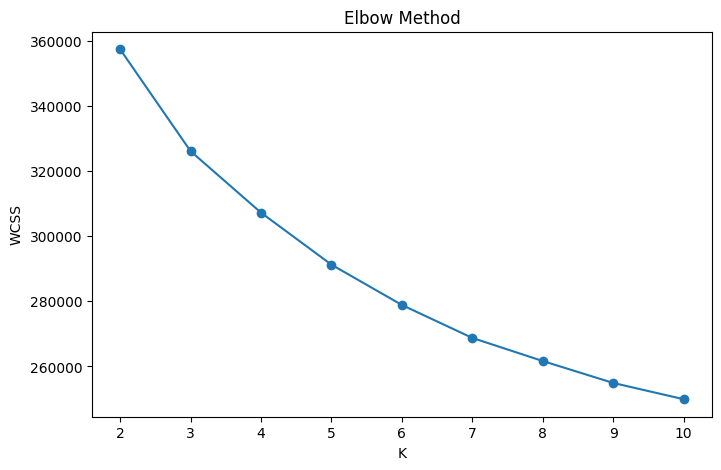

In [14]:
wcss = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_processed)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker="o")

plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

##KMeans Clustering

In [15]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_processed)

df["KMeans_Cluster"] = kmeans_labels

##Visualize KMeans Clusters

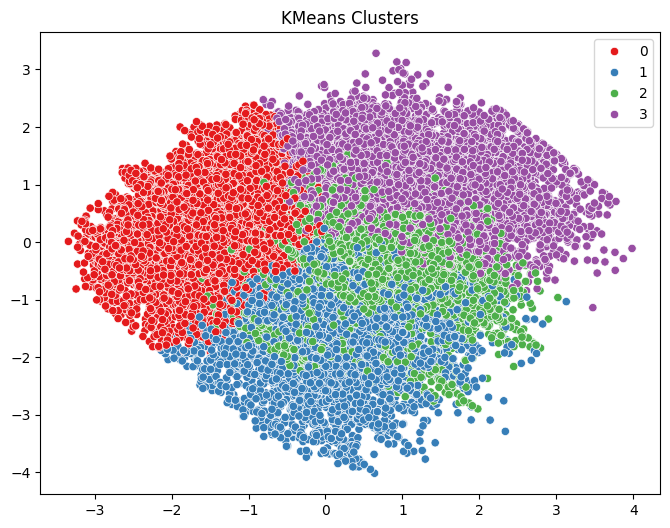

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=kmeans_labels,
    palette="Set1"
)

plt.title("KMeans Clusters")
plt.show()

##Agglomerative Clustering

In [ ]:
agg = AgglomerativeClustering(
    n_clusters=4
)

agg_labels = agg.fit_predict(X_processed.toarray())

df["Agglomerative_Cluster"] = agg_labels

##Cluster Profiling

In [18]:
cluster_profile = df.groupby(
    "KMeans_Cluster"
)[num_cols].mean()

cluster_profile

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
KMeans_Cluster,,,,,,
0,26.325606,205376.475997,9.265346,194.414415,45.398872,33.540030
1,55.447668,165204.079055,8.542386,691.199633,73.385138,35.009619
2,38.129296,193471.212373,8.987546,800.089133,88.626048,48.695571
3,41.418177,184716.215918,13.403589,2783.209438,150.564759,44.847771


##Cluster Size

In [19]:
df["KMeans_Cluster"].value_counts()

,count
KMeans_Cluster,
0,15248
2,12285
3,12037
1,9272


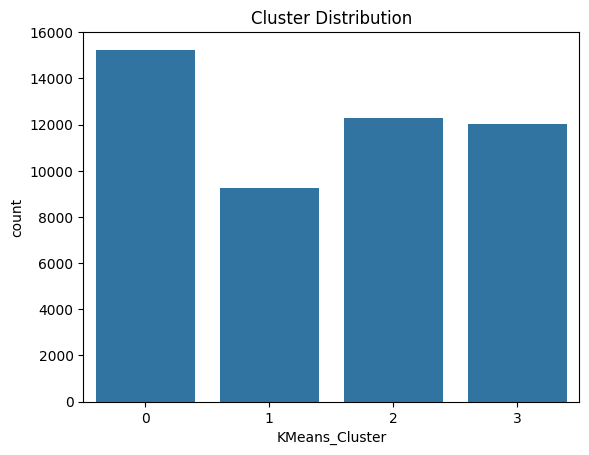

In [20]:
sns.countplot(
    x="KMeans_Cluster",
    data=df
)

plt.title("Cluster Distribution")
plt.show()

##Compare with Income

In [21]:
pd.crosstab(
    df["KMeans_Cluster"],
    df["income"],
    normalize="index"
) * 100

income,<=50K,<=50K.,>50K,>50K.
KMeans_Cluster,,,,
0,64.716684,32.640346,1.875656,0.767314
1,54.874892,28.440466,11.335203,5.349439
2,47.448107,22.865283,19.739520,9.947090
3,32.690870,16.715128,33.887181,16.706821


##Most Common Characteristics per Cluster

In [22]:
for cluster in sorted(df["KMeans_Cluster"].unique()):

    print("\n")
    print("="*50)
    print(f"Cluster {cluster}")
    print("="*50)

    cluster_df = df[df["KMeans_Cluster"] == cluster]

    for col in cat_cols:

        print(
            f"{col}:",
            cluster_df[col].mode()[0]
        )



Cluster 0
workclass: Private
education: HS-grad
marital-status: Never-married
occupation: Other-service
relationship: Own-child
race: White
sex: Female
native-country: United-States


Cluster 1
workclass: Private
education: HS-grad
marital-status: Married-civ-spouse
occupation: Adm-clerical
relationship: Husband
race: White
sex: Male
native-country: United-States


Cluster 2
workclass: Private
education: HS-grad
marital-status: Married-civ-spouse
occupation: Craft-repair
relationship: Husband
race: White
sex: Male
native-country: United-States


Cluster 3
workclass: Private
education: Bachelors
marital-status: Married-civ-spouse
occupation: Prof-specialty
relationship: Husband
race: White
sex: Male
native-country: United-States


##Policy Recommendations

In [23]:
#Cluster 0
#Younger workforce
#Lower education level
#Lower working hours
#Mostly lower income

#Recommendation:

#Skill development programs
#Vocational training

In [24]:
#Cluster 1
#Highly educated professionals
#Higher working hours
#Higher income proportion

#Recommendation:

#Tax planning policies
#Leadership development

In [25]:
#Cluster 2
#Mid-career workers
#Stable employment

#Recommendation:

#Financial literacy campaigns

In [26]:
#Cluster 3
#Older population
#Reduced work participation

#Recommendation:

#Retirement support schemes
#Healthcare assistance